In [1]:
# Calculate generalized Schwarz integral formulas
import importlib
import numpy as np
import matplotlib.pyplot as plt

import maps_core
import context
import alpha_prime

# Reload after editing .py files (one module at a time; dependency order)
importlib.reload(maps_core)
importlib.reload(context)
importlib.reload(alpha_prime)

from context import init_context
from alpha_prime import omega_alpha, dvalpha_dz, dvalpham_dz, G
from alpha_prime import dthetam, thetam, thetam_inv
from maps_core import real, imag, pi, log, sin, exp, prod, conj
from maps_core import is_inside_domain, diff



In [22]:
# Domain / Schottky parameters (owned by this notebook)
#
#qv = np.array([0.2, 0.1])
qv = np.array([0.4, 0.3])
#dv = np.array([0.5 , -0.5])
dv = np.array([0.5-0.2j, -0.5+0.1j])
#dv = np.array([0.5-0.2j, -0.5])
#qv = np.array([0.2,0.5,0.1])

#alpha = np.array([[np.pi / 5], [np.pi / 3]])
alpha = np.array([[np.pi / 2], [np.pi / 4]])
level = 10

init_context(qv, dv, alpha, level_in=level)


In [23]:
def f(z):
    return z

Nd = 2000
dth = 2*pi/Nd
zp = exp(1j*np.linspace(dth/2,2*pi-dth/2,Nd,endpoint=True))
zp_int = exp(1j*np.linspace(0,2*pi,Nd+1,endpoint=True))
ea = exp(1j*alpha)
eam = exp(-1j*alpha)

qzp0 = qv[0]*zp + dv[0]
qzp1 = qv[1]*zp + dv[1]
qzp0_int = qv[0]*zp_int + dv[0]
qzp1_int = qv[1]*zp_int + dv[1]
## --- boundary values --- 
r0 = real(f(zp))
r1 = real(ea[0]*f(qzp0))
r2 = real(ea[1]*f(qzp1))
a = 0.1+0.3j

print(is_inside_domain(a, qv, dv))
kerC0 = log(omega_alpha(zp_int,a)) + log(conj(omega_alpha(zp_int,1/conj(a))))
kerC10 = log(omega_alpha(qzp0_int,a))
kerC11 = log(conj(omega_alpha(qzp0_int,1/conj(a))))
kerC20 = log(omega_alpha(qzp1_int,a))
kerC21 = log(conj(omega_alpha(qzp1_int,1/conj(a))))
# numpy の unwrap 関数を使うと MATLAB の unwrap と同様の動作を実現できます．
kerC0_u =  real(kerC0) + 1j*np.unwrap(imag(kerC0))  
kerC10_u =  real(kerC10) + 1j*np.unwrap(imag(kerC10))  
kerC11_u =  real(kerC11) + 1j*np.unwrap(imag(kerC11))  
kerC20_u =  real(kerC20) + 1j*np.unwrap(imag(kerC20))  
kerC21_u =  real(kerC21) + 1j*np.unwrap(imag(kerC21))  
kerC1_u = eam[0]*kerC10_u + ea[0]*kerC11_u
kerC2_u = eam[1]*kerC20_u + ea[1]*kerC21_u

val0 = sum(r0 * diff(kerC0_u))/(2*pi*1j)
val1 = sum(r1 * diff(kerC1_u))/(2*pi*1j)
val2 = sum(r2 * diff(kerC2_u))/(2*pi*1j)
print(f(a))
print(val0-val1-val2)


cj = 0
c0_0 = sum(r0*dvalpha_dz(zp,alpha,cj)*1j*zp)*dth
c0_1 = eam[0]*sum(r1*dvalpha_dz(qzp0,alpha,cj)*1j*qv[0]*zp)*dth
c0_2 = eam[1]*sum(r2*dvalpha_dz(qzp1,alpha,cj)*1j*qv[1]*zp)*dth
c0 = 1/sin(alpha[cj])*(c0_0 - c0_1 - c0_2)
print(c0_0)
print(c0_1)
print(c0_2)

print(val0-val1-val2 + 1j*real(c0))


error = abs((f(a) - (val0-val1-val2 + 1j*real(c0)))/f(a))
print(error)

True
(0.1+0.3j)
(0.10000713280160886+0.3023041953820909j)
(0.055902329833194965+1.7372448572925233e-05j)
[0.24910486+0.18130582j]
[-0.190874+0.01220859j]
[0.10000713+0.29997567j]
[8.01863422e-05]


In [5]:
## Different formulation
def f1(z):
    return ea[0]*f(z)

r0 = real(eam[0]*f1(zp))
r1 = real(f1(qzp0))
r2 = real(ea[1]*eam[0]*f1(qzp1))

kerC00 = log(omega_alpha(zp_int,a))
kerC01 = log(conj(omega_alpha(zp_int,thetam(1/conj(a),0))))
kerC10 = log(omega_alpha(qzp0_int,a))
kerC11 = log(conj(omega_alpha(qzp0_int,thetam(1/conj(a),0))))
kerC20 = log(omega_alpha(qzp1_int,a))
kerC21 = log(conj(omega_alpha(qzp1_int,thetam(1/conj(a),0))))
# numpy の unwrap 関数を使うと MATLAB の unwrap と同様の動作を実現できます．
kerC00_u =  real(kerC00) + 1j*np.unwrap(imag(kerC00))  
kerC01_u =  real(kerC01) + 1j*np.unwrap(imag(kerC01))  
kerC10_u =  real(kerC10) + 1j*np.unwrap(imag(kerC10))  
kerC11_u =  real(kerC11) + 1j*np.unwrap(imag(kerC11))  
kerC20_u =  real(kerC20) + 1j*np.unwrap(imag(kerC20))  
kerC21_u =  real(kerC21) + 1j*np.unwrap(imag(kerC21))  

kerC0_u = ea[0]*kerC00_u + eam[0]*kerC01_u
kerC1_u = kerC10_u + kerC11_u
kerC2_u = ea[0]*eam[1]*kerC20_u + eam[0]*ea[1]*kerC21_u

val0 = sum(r0 * diff(kerC0_u))/(2*pi*1j)
val1 = sum(r1 * diff(kerC1_u))/(2*pi*1j)
val2 = sum(r2 * diff(kerC2_u))/(2*pi*1j)
print(f1(a))
print(val0-val1-val2)




    

[-0.09543388+0.30148362j]
(-0.09543361722688076+0.3000796752662987j)


In [9]:
# single-valued condition
def dmu_dz(z,m):
    return dvalpha_dz(z,alpha,m)/sin(alpha[m]) - dvalpha_dz(z,alpha,0)/sin(alpha[0])

s0 = sum(r0*dmu_dz(zp,1)*zp)*dth
s1 = eam[0]*sum(r1*dmu_dz(qzp0,1)*zp)*dth*qv[0]
s2 = eam[1]*sum(r2*dmu_dz(qzp1,1)*zp)*dth*qv[1]

print(s0 - s1 - s2)







[-1.06120444e-07+5.83422144e-10j]


In [161]:
a1 = 0.4+0.2j
a2 = 0.4-0.2j
print(omega_alpha(a1,a2))

(-0.07629991004840607+0.4909905760554626j)


In [47]:
np.linspace(0,2*pi,int(2*pi/dth)+1,endpoint=True)

array([0.00000000e+00, 1.57118912e-03, 3.14237825e-03, ...,
       6.28004293e+00, 6.28161412e+00, 6.28318531e+00], shape=(4000,))

In [50]:
int(2*pi/dth)

3999

In [159]:
eam[0]*dvalpham_dz(thetam(zp,0),alpha,0)*dthetam(zp,0) - ea[0]*dvalpham_dz(zp,alpha,0)

array([-3.71571415e-01-0.08294623j, -3.69341248e-01-0.07600487j,
       -3.66968786e-01-0.06921292j, -3.64464591e-01-0.06257225j,
       -3.61838839e-01-0.05608422j, -3.59101300e-01-0.0497497j ,
       -3.56261336e-01-0.0435691j , -3.53327898e-01-0.03754244j,
       -3.50309524e-01-0.03166935j, -3.47214340e-01-0.02594913j,
       -3.44050066e-01-0.02038076j, -3.40824020e-01-0.01496293j,
       -3.37543130e-01-0.00969409j, -3.34213939e-01-0.00457248j,
       -3.30842617e-01+0.00040388j, -3.27434974e-01+0.00523714j,
       -3.23996467e-01+0.00992959j, -3.20532221e-01+0.01448366j,
       -3.17047033e-01+0.01890188j, -3.13545390e-01+0.02318688j,
       -3.10031483e-01+0.02734137j, -3.06509219e-01+0.0313681j ,
       -3.02982233e-01+0.0352699j , -2.99453903e-01+0.03904959j,
       -2.95927362e-01+0.04271005j, -2.92405511e-01+0.04625414j,
       -2.88891032e-01+0.04968476j, -2.85386400e-01+0.05300477j,
       -2.81893890e-01+0.05621703j, -2.78415596e-01+0.05932437j,
       -2.74953435e-01+0.

In [20]:
# MATLAB vj / diff(vj) via matlab_prime (kernel: Python (matlab_engine))
# maps_core も diff を export するので、こちらは diff_vj を使う
import importlib
import matlab_prime
importlib.reload(matlab_prime)
from matlab_prime import vj, dvj, diff_vj

vj.init(qv, dv)


In [21]:
# Evaluate vj and diff(vj)
z_test = complex(a) if "a" in globals() else 0.3 + 0.58j
print("vj.v1 =", vj.v1(z_test))
print("vj.v2 =", vj.v2(z_test))
print("diff_vj(vj).v1 =", diff_vj(vj).v1(z_test))
print("dvj.v2 =", dvj.v2(z_test))
print("dvj(1, zs) =", dvj(1, np.array([z_test, 0.1 + 0.2j])))


vj.v1 = (-0.08835148654228782+0.034963014531497374j)
vj.v2 = (0.07540653542449736+0.028413598503577248j)
diff_vj(vj).v1 = (-0.12300675651811503-0.008889020606861316j)
dvj.v2 = (-0.07113891506200037-0.07042012510500638j)
dvj(1, zs) = [-0.12300676-0.00888902j -0.13783549+0.11931731j]


(np.float64(-1.099994571722044),
 np.float64(1.099994571722044),
 np.float64(-1.099994571722044),
 np.float64(1.099994571722044))

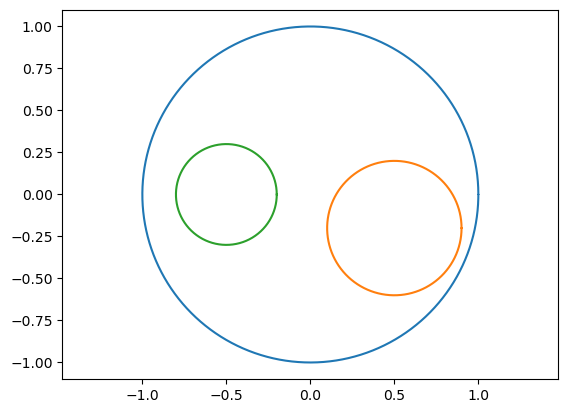

In [8]:
plt.plot(zp.real, zp.imag)
plt.plot(qzp0.real, qzp0.imag)
plt.plot(qzp1.real, qzp1.imag)
plt.axis('equal')